To compute: 
* tot item and % pa of that items
* numb of days
* persistency?

 -> instable grids? from grid with highest item per pa to PA 

 Instead of dominance being:

“PA with most items”

It now becomes:

“PA with highest structural presence + stability”

# How to infer PA areas from SLM into Kompass sales location grid code

In [1]:
import json
import pandas as pd
from google.cloud import bigquery
import requests
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd

import re
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
import matplotlib.colors as mcolors

import folium
import branca


ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/salvatore.lovecchio/Library/Python/3.9/lib/python/site-packages/traitlets/traitlets.py", line 632, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/salvatore.lovecchio/Library/Python/3.9/lib/python/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/Users/salvatore.lovecchio/Library/Python/3.9/lib/python/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/Users/salvatore.lovecchio/Library/Python/3.9/lib/python/site-packages/traitlets/traitlets.py", line 687, in __get__
    return t.cast(G, self.get(obj, cls))  # the G should encode the Optional
  File "/Users/salvatore.lovecchio/Library/Python/3.9/lib/python/site-packages/traitlets/t

In [2]:
client = bigquery.Client(project="ingka-sot-cfm-dev")


/Users/salvatore.lovecchio/Library/Python/3.9/lib/python/site-packages/google/auth/_default.py:76: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


In [3]:
##sec  : data from fixa room setting
code=""" 
SELECT
  slm.article_id,
  it.item_no,
  it.item_name,
  it.pa_no,
  it.pa_name,
  it.hfb_name,
  it.hfb_no,
  slm.bu_code,
  slm.sales_location_id,
  slm.active,
  slm.location_type,
  PARSE_DATE('%Y%m%d', slm.from_date) AS from_date,
  slm.import_date AS till_date,
  ROW_NUMBER()
    OVER (
      PARTITION BY
        slm.article_id, slm.bu_code, slm.sales_location_id, slm.from_date
      ORDER BY CAST(slm.import_date AS DATE) DESC
    ) AS row_num
FROM `ingka-cff-slm-prod.slm.article_location_weekly` AS slm
LEFT JOIN
  `ingka-rrm-erix-prod.erix_legacy_production.item_dim` it
  ON
    it.item_no = slm.article_id
WHERE
  1 = 1
  AND import_date >= '2025-09-01'
  AND import_date <= '2026-01-31'
  AND bu_code = '274'
  AND active = '1'
  AND location_type IN ('2', '3') -- we take into account only the item in Primary or Home/primare location
  AND sales_location_id LIKE 'M%'  -- we take into account only Markethall for the moment
QUALIFY row_num = 1

"""

job=client.query(code)

item_location=job.to_dataframe()

E0000 00:00:1771496281.748766 49510122 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


In [4]:
item_location.head()

,article_id,item_no,item_name,pa_no,pa_name,hfb_name,hfb_no,bu_code,sales_location_id,active,location_type,from_date,till_date,row_num
0,00578497,00578497,VINTERFINT 2024 deco 71 Santa Claus grey/red,1637,Holiday decoration,Decoration,16,274,M16B01,1,3,2025-10-08,2026-01-11,1
1,10306019,10306019,BOTAREN shower curtain rod 70-120 white,1133,Shower curtains and accessories,Bed and bath textiles,11,274,M06F17,1,3,2024-05-02,2026-01-31,1
2,20512976,20512976,BJÄLVEN N bath robe L/XL beige,1135,Bath textile accessories,Bed and bath textiles,11,274,M06C15,1,3,2025-06-20,2026-01-31,1
3,40430164,40430164,VÄLVÅRDAD dish-washing brush stainless steel/b...,1433,Washing up,Cooking,14,274,M15R17,1,3,2024-06-04,2026-01-14,1
4,40559680,40559680,FINFÖRDELA bendable chopp brd 28x36 grn/bgrn 2p,1424,Chopping boards,Cooking,14,274,M14R11,1,3,2025-06-29,2025-09-14,1


In [58]:
item_location.loc[item_location.pa_no.astype(str).str.startswith('14')].pa_no.nunique()

12

In [37]:
item_location.loc[(item_location.till_date>pd.to_datetime("2026-01-23").date()) & (item_location.sales_location_id =='M14U12') ].item_no.unique()

array(['40449192', '80298474', '90602172', '90555712', '30580899',
       '80580095', '60463686', '30613116', '20582733', '70554515',
       '50613115', '00545218', '00587171', '70602516', '00463689',
       '50555709', '60324544', '90580896', '00580099', '80602511',
       '60580893', '00580891'], dtype=object)

## Sect 1. :  Visualize the dominant weekly PA per grid into Kompass map

In [5]:
## determine the dominant PA by just ranking per n item with the most common PA per grid 
df = item_location.copy()

df["from_date"] = pd.to_datetime(df["from_date"])
df["till_date"] = pd.to_datetime(df["till_date"]).fillna(pd.Timestamp("today"))

# number of days active (inclusive)
n_days = (df["till_date"] - df["from_date"]).dt.days + 1

df_expanded = df.loc[df.index.repeat(n_days)].copy()

# offset per repeated row
offset = df_expanded.groupby(level=0).cumcount()

# ✅ add Timedelta, not integer
df_expanded["date"] = df_expanded["from_date"] + pd.to_timedelta(offset, unit="D")

# ISO year-week
iso = df_expanded["date"].dt.isocalendar()
df_expanded["year_week"] = iso["year"].astype(str) + "-" + iso["week"].astype(str).str.zfill(2)

dominant_pa = (
    df_expanded
    .groupby(["year_week", "sales_location_id", "pa_no"])["article_id"]
    .nunique()
    .reset_index(name="n_items")
    .sort_values("n_items", ascending=False)
    .drop_duplicates(["year_week", "sales_location_id"])
    [["year_week", "sales_location_id", "pa_no", "n_items"]]
)


#### visualize it into the map

In [6]:
import pandas as pd
import geopandas as gpd
import re
import folium
import branca

# -----------------------
# Inputs
# -----------------------
GEO_PATH = "Kompass_Barendrecth/floor1.geojson"
YEAR_WEEK = "2026-04"   # choose the week you want to visualize
HFB_CODE = "14"         # department code (HFB14)

POINT_RADIUS = 7

# dominant_pa must contain: year_week, sales_location_id, pa_no, n_items
dominant_pa["year_week"] = dominant_pa["year_week"].astype(str)
dominant_pa["sales_location_id"] = dominant_pa["sales_location_id"].astype(str).str.upper().str.strip()

# -----------------------
# Read geojson
# -----------------------
gdf_all = gpd.read_file(GEO_PATH)
gdf_poly  = gdf_all[gdf_all.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()
gdf_point = gdf_all[gdf_all.geometry.type.eq("Point")].copy()

if gdf_poly.crs is None:
    gdf_poly = gdf_poly.set_crs(4326, allow_override=True)
if gdf_point.crs is None:
    gdf_point = gdf_point.set_crs(gdf_poly.crs, allow_override=True)

# Clean point fields
gdf_point["areaLetter"] = gdf_point["areaLetter"].astype("string").str.strip().str.upper()
gdf_point = gdf_point[gdf_point["areaLetter"].isin(["S", "M"])].copy()
gdf_point["coord_raw"] = gdf_point["coordinate"].astype("string").str.strip()

# Identify dept polygon id field
poly_dept_col = next(
    (c for c in gdf_poly.columns if c != "geometry" and
     gdf_poly[c].astype(str).str.contains(r"DEPT_\d{3}", regex=True, na=False).any()),
    None
)
if poly_dept_col is None:
    raise ValueError("No polygon property with a 'DEPT_###' id found.")

# Spatial join points -> dept polygons
poly_keep = gdf_poly[[poly_dept_col, "geometry"]].rename(columns={poly_dept_col: "parent_dept"})
pts = gpd.sjoin(gdf_point, poly_keep, how="left", predicate="within").drop(columns=["index_right"])

# Dept mapping (your mapping)
dept_map = {
    "DEPT_009":"01","DEPT_016":"02","DEPT_012":"03",
    "DEPT_013":"04,05","DEPT_022":"04","DEPT_023":"05",
    "DEPT_005":"06","DEPT_019":"06","DEPT_018":"06",
    "DEPT_011":"07,70","DEPT_024":"07","DEPT_025":"70",
    "DEPT_010":"08","DEPT_014":"09","DEPT_002":"10",
    "DEPT_008":"11","DEPT_007":"12","DEPT_006":"13",
    "DEPT_003":"14,15","DEPT_020":"14","DEPT_021":"15",
    "DEPT_004":"16","DEPT_026":"17","DEPT_001":"18","DEPT_017":"96",
}
def dept_to_codes(dept):
    m = re.search(r"DEPT_\d{3}", str(dept))
    if not m:
        return []
    mapped = dept_map.get(m.group(0))
    return [x.strip() for x in mapped.split(",")] if mapped else []

# Build location_code(s)
pts["location_code"] = pts.apply(
    lambda r: [f"{r['areaLetter']}{d}{r['coord_raw']}" for d in dept_to_codes(r["parent_dept"])],
    axis=1
)
pts = pts.explode("location_code", ignore_index=True)
pts["location_code"] = pts["location_code"].astype(str).str.upper().str.strip()

# -----------------------
# Keep ONLY HFB14 grid points
# -----------------------
pts_hfb = pts[pts["location_code"].str.startswith(("M14", "M15"), na=False)].copy()

# ✅ build join key = last 3 chars
pts_hfb["loc3"] = pts_hfb["location_code"].str[-3:]

# -----------------------
# Join dominant PA for the chosen week (using last 3 chars)
# -----------------------
dom_week = dominant_pa[dominant_pa["year_week"] == YEAR_WEEK].copy()
dom_week = dom_week.rename(columns={"sales_location_id": "location_code"})

dom_week["loc3"] = dom_week["location_code"].astype(str).str.upper().str.strip().str[-3:]  ## we join only in the last 3 caracter of the location because there are PA of HFB 15 in dep 14

pts_hfb = pts_hfb.merge(
    dom_week[["loc3", "pa_no", "n_items"]],
    on="loc3",
    how="left"
)

# -----------------------
# Build a color map for PA numbers
# -----------------------
pa_values = sorted([p for p in pts_hfb["pa_no"].dropna().unique()])
if len(pa_values) == 0:
    raise ValueError("No PA matches found for this week + HFB filter. Check YEAR_WEEK / location codes.")

palette = branca.colormap.linear.Set1_09.scale(0, max(1, len(pa_values)-1))
pa_to_color = {pa: palette(i) for i, pa in enumerate(pa_values)}

# -----------------------
# Plot map
# -----------------------
gdf_poly_w = gdf_poly.to_crs(4326)
pts_wgs84 = pts_hfb.to_crs(4326)

center = pts_wgs84.geometry.unary_union.centroid
m = folium.Map(location=[center.y, center.x], zoom_start=22, tiles="CartoDB Positron", control_scale=True)

# Polygons behind
folium.GeoJson(
    gdf_poly_w.__geo_interface__,
    name="Departments",
    style_function=lambda _:{ "fillOpacity": 0, "color": "#333333", "weight": 1.0 }
).add_to(m)

######## this part is for the colour palette ############
# --- Extract PA lists per HFB ---
pa_hfb14 = sorted(
    dominant_pa.loc[
        dominant_pa["sales_location_id"].str.startswith("M14", na=False),
        "pa_no"
    ].dropna().unique()
)

pa_hfb15 = sorted(
    dominant_pa.loc[
        dominant_pa["sales_location_id"].str.startswith("M15", na=False),
        "pa_no"
    ].dropna().unique()
)

# --- Build discrete categorical palette ---
def build_palette(pa_values, cmap_name="tab20"):
    cmap = plt.get_cmap(cmap_name)
    colors = [mcolors.to_hex(cmap(i / max(1, len(pa_values)-1)))
              for i in range(len(pa_values))]
    return dict(zip(pa_values, colors))

pa14_to_color = build_palette(pa_hfb14, cmap_name="tab20")
pa15_to_color = build_palette(pa_hfb15, cmap_name="tab20b")



##################

# Points colored by PA
for _, r in pts_wgs84.iterrows():
    code = r["location_code"]
    pa = r["pa_no"]
    n_items = r["n_items"]

   # c = pa_to_color.get(pa, "#BBBBBB")

    if str(code).startswith("M14"):
        c = pa14_to_color.get(pa, "#BBBBBB")
    elif str(code).startswith("M15"):
        c = pa15_to_color.get(pa, "#BBBBBB")
    else:
        c = "#BBBBBB"

    tooltip = f"{code} | key={r['loc3']} | PA: {pa} | n_items: {n_items}"

    folium.CircleMarker(
        location=[r.geometry.y, r.geometry.x],
        radius=POINT_RADIUS,
        color=c,
        weight=2,
        fill=True,
        fill_color=c,
        fill_opacity=0.9,
        tooltip=tooltip
    ).add_to(m)

# Legend
palette.caption = f"PA (dominant) — {YEAR_WEEK} — HFB{HFB_CODE} (join by last 3 chars)"
palette.add_to(m)

# Fit bounds
bounds = pts_wgs84.total_bounds
m.fit_bounds([[bounds[1], bounds[0]], [bounds[3], bounds[2]]])

folium.LayerControl().add_to(m)
m


/var/folders/69/q_vmc6ns6_v503hjpfz65h8r0000gp/T/ipykernel_98714/883223475.py:114: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  center = pts_wgs84.geometry.unary_union.centroid


## Explore how "stable" are those PA defined grids


Create a heatmap of instability across the whole department

Add rolling smoothing (2-week smoothing)

Detect structural PA boundary shifts automatically

In [7]:

# -------------------------------------------------
# 1) Prepare data
# -------------------------------------------------
df = item_location.copy()

df["from_date"] = pd.to_datetime(df["from_date"])
df["till_date"] = pd.to_datetime(df["till_date"]).fillna(pd.Timestamp("today"))

# number of active days (inclusive)
n_days = (df["till_date"] - df["from_date"]).dt.days + 1

# expand each row to daily granularity
df_expanded = df.loc[df.index.repeat(n_days)].copy()

# daily offset per row
offset = df_expanded.groupby(level=0).cumcount()

df_expanded["date"] = df_expanded["from_date"] + pd.to_timedelta(offset, unit="D")

# -------------------------------------------------
# 2) Create ISO year-week
# -------------------------------------------------
iso = df_expanded["date"].dt.isocalendar()
df_expanded["year_week"] = (
    iso["year"].astype(str) + "-" +
    iso["week"].astype(str).str.zfill(2)
)

# -------------------------------------------------
# 3) Days per item (persistence at daily level)
# -------------------------------------------------
days_per_item = (
    df_expanded
    .groupby(["year_week", "sales_location_id", "pa_no", "article_id"])
    .size()
    .reset_index(name="n_days_item")
)

# -------------------------------------------------
# 4) Aggregate per PA inside each grid
# -------------------------------------------------
pa_stats = (
    days_per_item
    .groupby(["year_week", "sales_location_id", "pa_no"])
    .agg(
        n_items_pa=("article_id", "nunique"),
        avg_days_pa=("n_days_item", "mean")
    )
    .reset_index()
)

# -------------------------------------------------
# 5) Total distinct items per grid
# -------------------------------------------------
total_items = (
    days_per_item
    .groupby(["year_week", "sales_location_id"])
    .agg(n_items_total=("article_id", "nunique"))
    .reset_index()
)

# -------------------------------------------------
# 6) Merge totals + compute PA share
# -------------------------------------------------
pa_stats = pa_stats.merge(
    total_items,
    on=["year_week", "sales_location_id"],
    how="left"
)

pa_stats["pa_share"] = pa_stats["n_items_pa"] / pa_stats["n_items_total"]

# -------------------------------------------------
# 7) Optional: Dominance score (share × persistence)
# -------------------------------------------------
pa_stats["dominance_score"] = (
    pa_stats["pa_share"] * pa_stats["avg_days_pa"]
)

# -------------------------------------------------
# 8) Extract dominant PA per grid (robust version)
# -------------------------------------------------
dominant_pa = (
    pa_stats
    .sort_values("dominance_score", ascending=False)
    .drop_duplicates(["year_week", "sales_location_id"])
    [["year_week",
      "sales_location_id",
      "pa_no",
      "n_items_pa",
      "n_items_total",
      "pa_share",
      "avg_days_pa",
      "dominance_score"]]
)

# -------------------------------------------------
# Results
# -------------------------------------------------
print("PA stats per grid:")
display(pa_stats.head())

print("Dominant PA per grid:")
display(dominant_pa.head())


PA stats per grid:


,year_week,sales_location_id,pa_no,n_items_pa,avg_days_pa,n_items_total,pa_share,dominance_score
0,2018-22,M12N15,1214,1,4.0,1,1.0,4.0
1,2018-23,M12N15,1214,1,7.0,1,1.0,7.0
2,2018-24,M12N15,1214,1,7.0,1,1.0,7.0
3,2018-25,M12N15,1214,1,7.0,1,1.0,7.0
4,2018-26,M12N15,1214,1,7.0,1,1.0,7.0


Dominant PA per grid:


,year_week,sales_location_id,pa_no,n_items_pa,n_items_total,pa_share,avg_days_pa,dominance_score
32142,2025-47,M10H13,1012,1,1,1.0,11.00,11.00
25497,2025-37,M10I16,1023,2,2,1.0,9.50,9.50
25860,2025-37,M16C04,1621,4,4,1.0,8.50,8.50
25930,2025-37,M16F07,1623,5,5,1.0,8.40,8.40
28365,2025-41,M14S16,1431,4,4,1.0,8.25,8.25


In [18]:
pa_stats.loc[(pa_stats.year_week =='2026-04') & (pa_stats.sales_location_id =='M14U10')]

,year_week,sales_location_id,pa_no,n_items_pa,avg_days_pa,n_items_total,pa_share,dominance_score
38450,2026-04,M14U10,1411,2,7.0,2,1.0,7.0


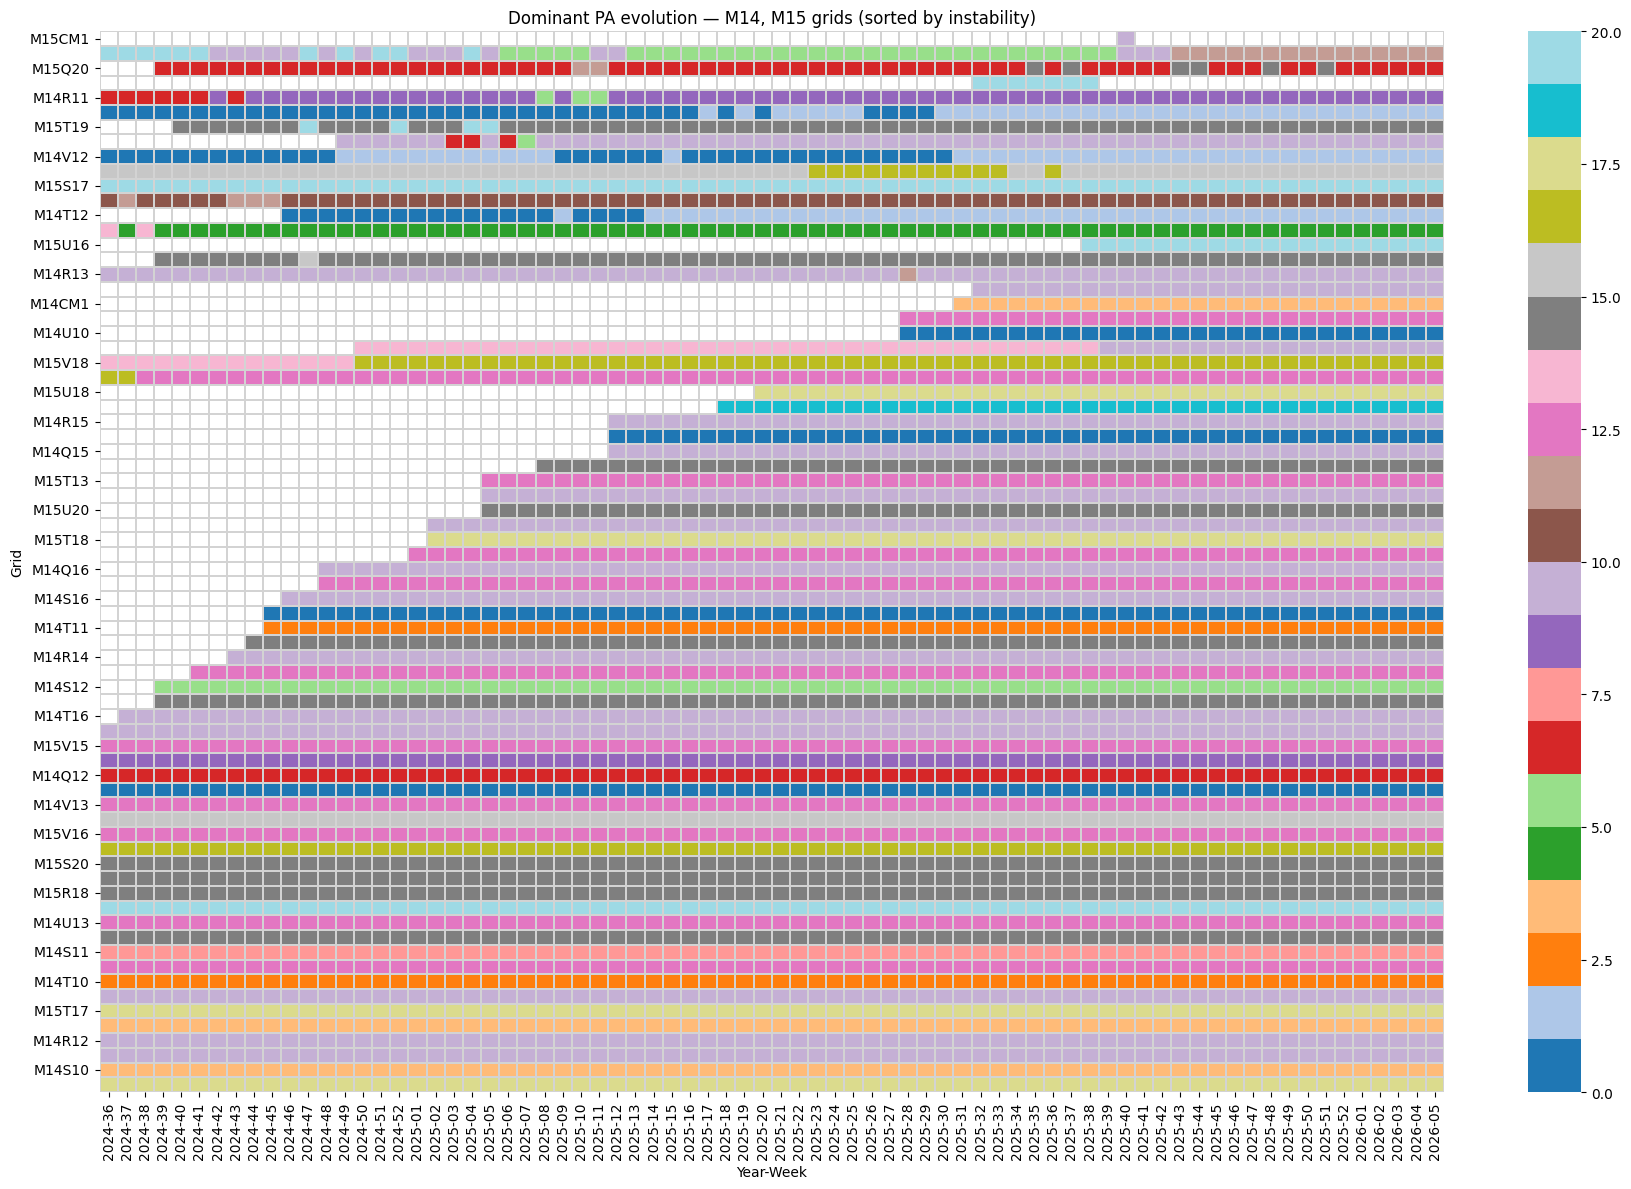

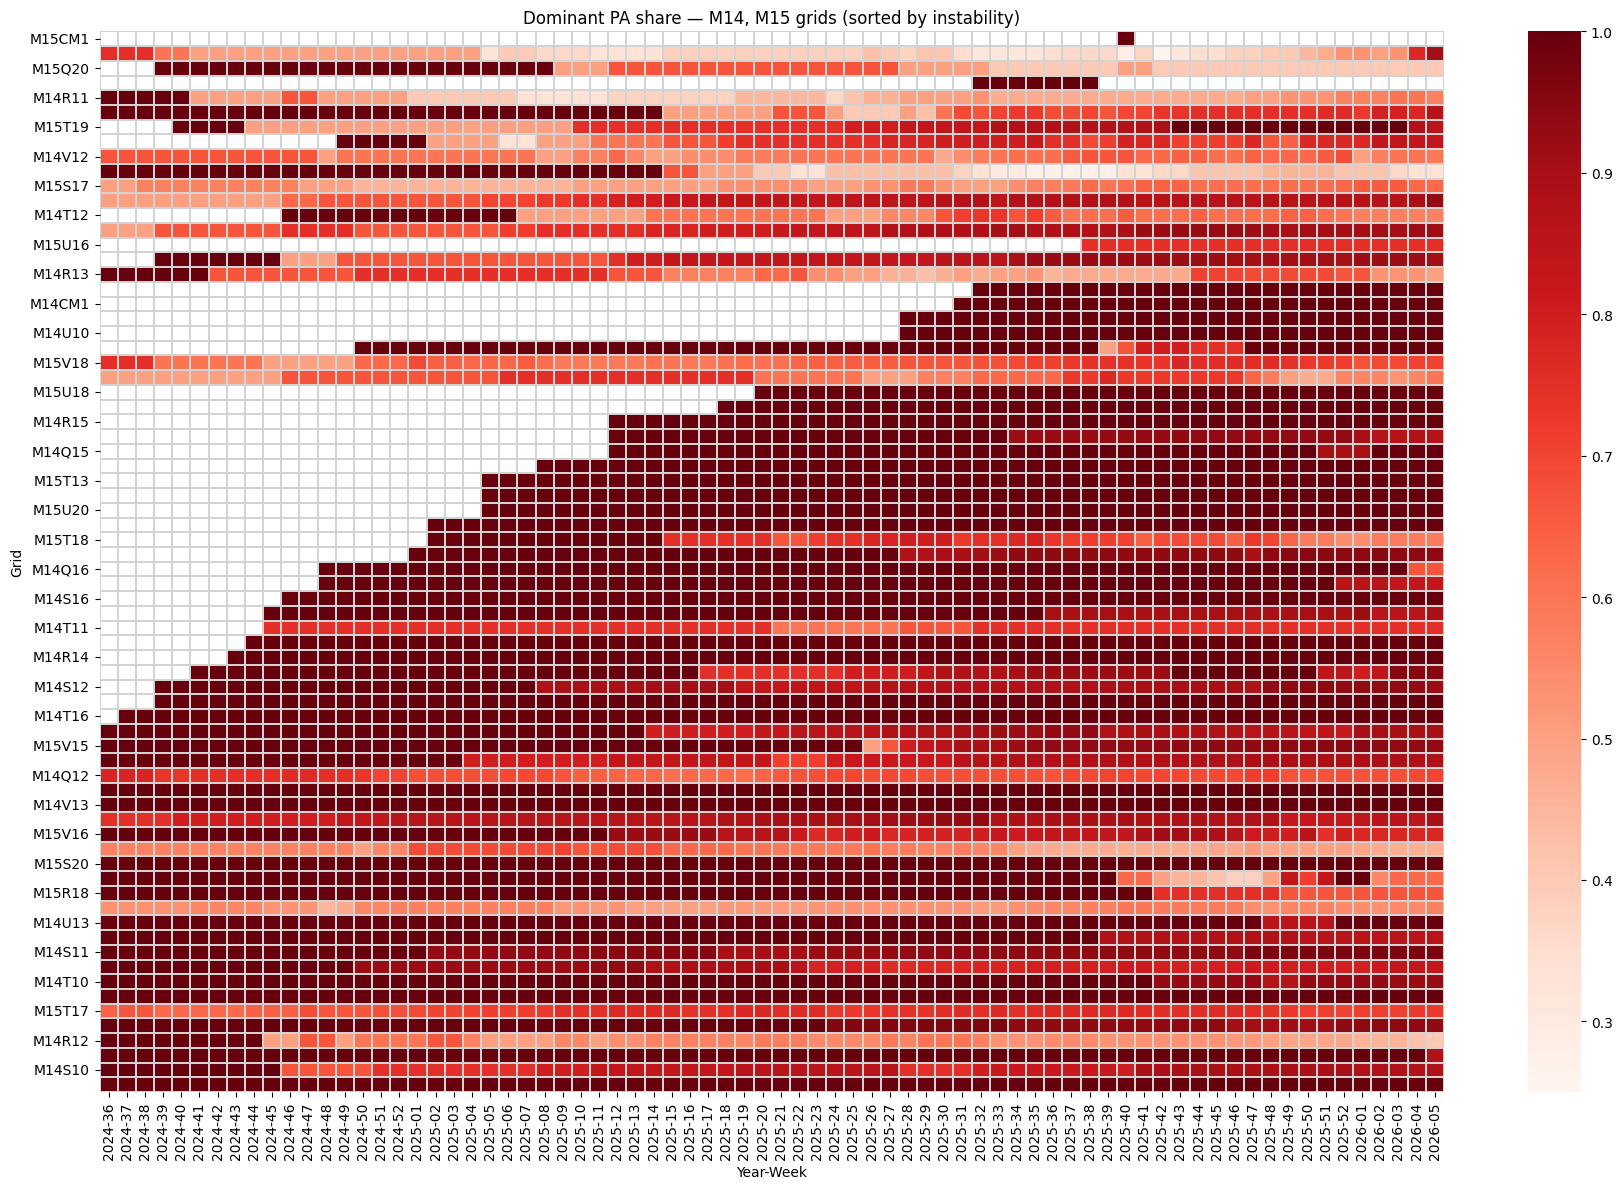

,sales_location_id,n_weeks,n_changes,instability_ratio
38,M15CM1,1,1,1.000000
18,M14S13,74,15,0.202703
41,M15Q20,71,13,0.183099
33,M14U16,7,1,0.142857
9,M14R11,74,8,0.108108
30,M14U12,74,8,0.108108
54,M15T19,70,7,0.100000
4,M14Q13,61,6,0.098361
36,M14V12,74,6,0.081081
70,M15V19,74,5,0.067568


In [16]:

# =================================================
# Settings
# =================================================
START_WEEK = "2024-36"    # "2024-36"                 # from Sept 2024 onward (ISO year-week)
GRID_PREFIXES = ("M14", "M15")         # include M14 and M15
PA_CMAP = "tab20"                      # categorical palette for PA IDs
SHARE_CMAP = "Reds"                    # intensity palette for PA share

# =================================================
# 1) Filter data (M14 + M15) and timeframe
# =================================================
df = dominant_pa.copy()

df = df[df["sales_location_id"].astype(str).str.startswith(GRID_PREFIXES, na=False)].copy()
df["year_week"] = df["year_week"].astype(str)

# keep from START_WEEK onward
df = df[df["year_week"] >= START_WEEK].copy()

# sort
df = df.sort_values(["sales_location_id", "year_week"]).reset_index(drop=True)

# =================================================
# 2) Compute instability (week-to-week PA changes per grid)
# =================================================
df["prev_pa"] = df.groupby("sales_location_id")["pa_no"].shift(1)
df["changed"] = df["pa_no"] != df["prev_pa"]

instability = (
    df.groupby("sales_location_id")
      .agg(n_weeks=("year_week", "nunique"),
           n_changes=("changed", "sum"))
      .reset_index()
)
instability["instability_ratio"] = instability["n_changes"] / instability["n_weeks"]

inst_map = instability.set_index("sales_location_id")["instability_ratio"]

# =================================================
# 3) Build pivots (grid x week)
# =================================================
pivot_pa = df.pivot(index="sales_location_id", columns="year_week", values="pa_no")
pivot_share = df.pivot(index="sales_location_id", columns="year_week", values="pa_share")

# sort rows by instability (highest instability on top)
pivot_pa["instability"] = pivot_pa.index.map(inst_map)
pivot_share["instability"] = pivot_share.index.map(inst_map)

pivot_pa_sorted = pivot_pa.sort_values("instability", ascending=False).drop(columns="instability")
pivot_share_sorted = pivot_share.sort_values("instability", ascending=False).drop(columns="instability")

# =================================================
# 4) Convert PA to numeric ids for the categorical heatmap
#    (keeps stable mapping)
# =================================================
pa_values = sorted(pd.unique(df["pa_no"].dropna()))
pa_to_int = {pa: i for i, pa in enumerate(pa_values)}
pivot_pa_num = pivot_pa_sorted.replace(pa_to_int)

# =================================================
# 5) Plot 1: Dominant PA evolution (categorical)
# =================================================
plt.figure(figsize=(18, 12))
ax = sns.heatmap(
    pivot_pa_num,
    cmap=PA_CMAP,
    linewidths=0.05,
    linecolor="lightgrey",
    cbar=True
)
ax.set_title(f"Dominant PA evolution — {', '.join(GRID_PREFIXES)} grids (sorted by instability)")
ax.set_xlabel("Year-Week")
ax.set_ylabel("Grid")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# =================================================
# 6) Plot 2: PA share evolution (intensity)
# =================================================
plt.figure(figsize=(18, 12))
ax2 = sns.heatmap(
    pivot_share_sorted,
    cmap=SHARE_CMAP,
    linewidths=0.05,
    linecolor="lightgrey",
    cbar=True
)
ax2.set_title(f"Dominant PA share — {', '.join(GRID_PREFIXES)} grids (sorted by instability)")
ax2.set_xlabel("Year-Week")
ax2.set_ylabel("Grid")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# (optional) inspect instability table
display(instability.sort_values("instability_ratio", ascending=False).head(20))


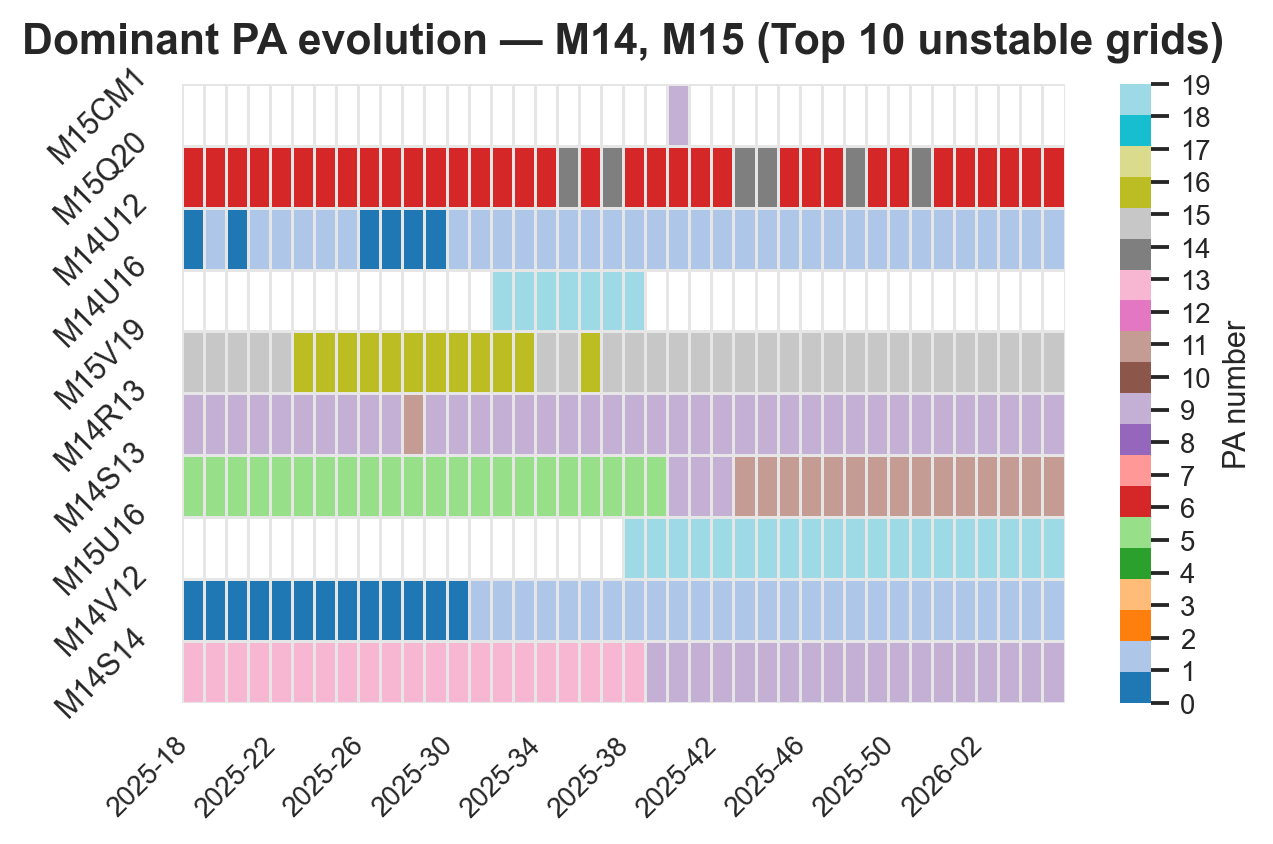

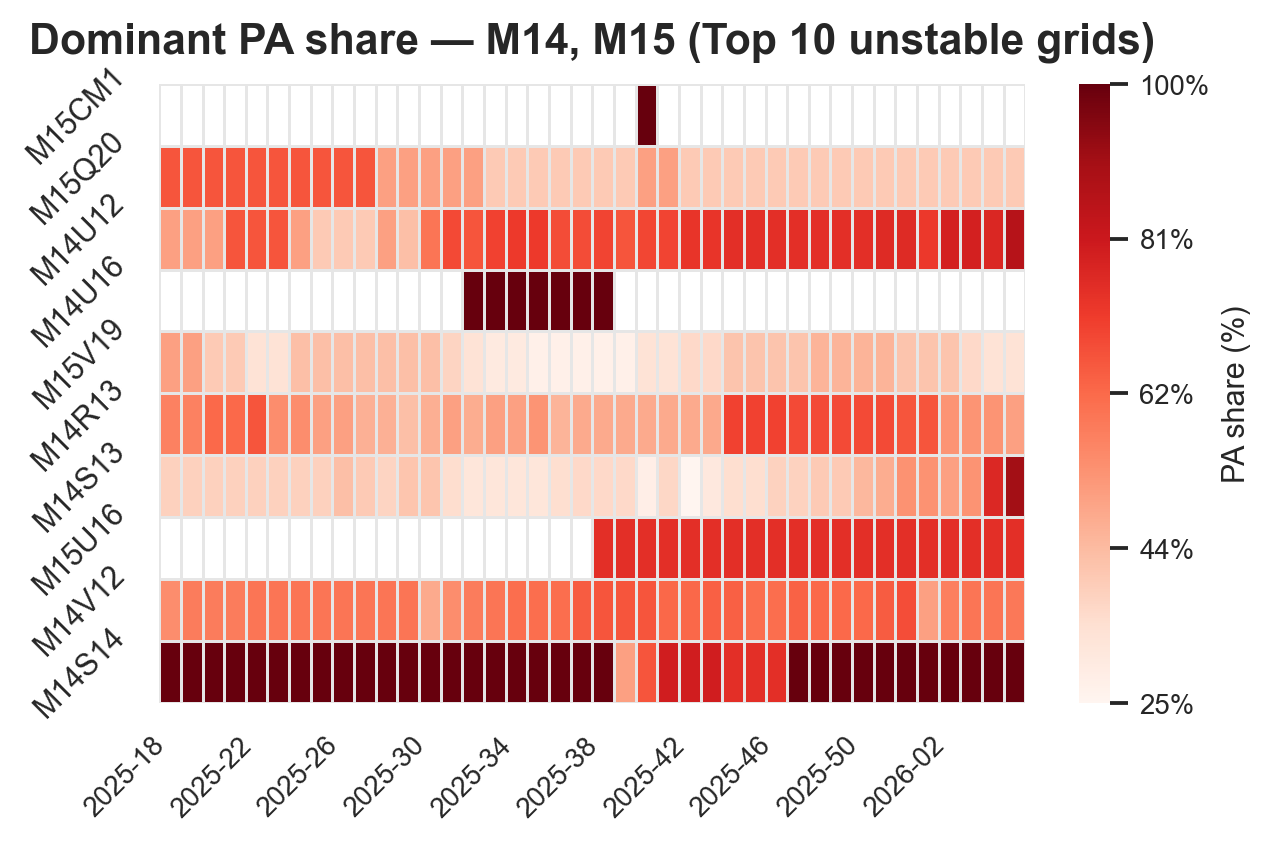

In [53]:
### this part is just for the ppt MI image

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# =================================================
# Settings
# =================================================
START_WEEK    = "2025-18"
GRID_PREFIXES = ("M14", "M15")
PA_CMAP       = "tab20"
SHARE_CMAP    = "Reds"

TOP_N_GRIDS   = 10
FIGSIZE       = (6, 4)
DPI           = 220

sns.set_theme(style="white")

# =================================================
# 1) Filter data
# =================================================
df = dominant_pa.copy()

df["sales_location_id"] = df["sales_location_id"].astype(str).str.upper().str.strip()
df["year_week"] = df["year_week"].astype(str)

df = df[df["sales_location_id"].str.startswith(GRID_PREFIXES, na=False)].copy()
df = df[df["year_week"] >= START_WEEK].copy()
df = df.sort_values(["sales_location_id", "year_week"]).reset_index(drop=True)

# =================================================
# 2) Instability
# =================================================
df["prev_pa"] = df.groupby("sales_location_id")["pa_no"].shift(1)
df["changed"] = df["pa_no"] != df["prev_pa"]

instability = (
    df.groupby("sales_location_id")
      .agg(n_weeks=("year_week", "nunique"),
           n_changes=("changed", "sum"))
      .reset_index()
)

instability["instability_ratio"] = (instability["n_changes"] / instability["n_weeks"]).fillna(0)
inst_map = instability.set_index("sales_location_id")["instability_ratio"]

# =================================================
# 3) Pivots
# =================================================
pivot_pa = df.pivot(index="sales_location_id", columns="year_week", values="pa_no")
pivot_share = df.pivot(index="sales_location_id", columns="year_week", values="pa_share")

pivot_pa["instability"] = pivot_pa.index.map(inst_map)
pivot_share["instability"] = pivot_share.index.map(inst_map)

pivot_pa_sorted = pivot_pa.sort_values("instability", ascending=False).drop(columns="instability")
pivot_share_sorted = pivot_share.sort_values("instability", ascending=False).drop(columns="instability")

pivot_pa_sorted = pivot_pa_sorted.head(TOP_N_GRIDS)
pivot_share_sorted = pivot_share_sorted.loc[pivot_pa_sorted.index]

# =================================================
# 4) PA -> integer mapping (stable)
# =================================================
pa_values = sorted(pd.unique(df["pa_no"].dropna()))
pa_to_int = {pa: i for i, pa in enumerate(pa_values)}
pivot_pa_num = pivot_pa_sorted.replace(pa_to_int)

# =================================================
# Helper for x ticks (safe version)
# =================================================
def thin_xticks(ax, max_labels=14):
    ticks = ax.get_xticks()
    labels = [t.get_text() for t in ax.get_xticklabels()]
    n = len(labels)
    if n == 0:
        return
    step = max(1, int(np.ceil(n / max_labels)))
    keep_idx = np.arange(0, n, step)

    ax.set_xticks(ticks[keep_idx])
    ax.set_xticklabels([labels[i] for i in keep_idx], rotation=90, fontsize=9)

# =================================================
# 5) Fig 1: Dominant PA evolution
# =================================================
plt.figure(figsize=FIGSIZE, dpi=DPI)
ax = sns.heatmap(
    pivot_pa_num,
    cmap=PA_CMAP,
    linewidths=0.4,
    linecolor="#E6E6E6",
    cbar=True
)

ax.set_title(f"Dominant PA evolution — {', '.join(GRID_PREFIXES)} (Top {TOP_N_GRIDS} unstable grids)",
             fontsize=14, weight="bold", pad=10)
ax.set_xlabel("", fontsize=11)
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=10)
plt.yticks(rotation=45)

thin_xticks(ax, max_labels=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

# --- Colorbar with integer ticks only ---
cbar = ax.collections[0].colorbar
n_pa = len(pa_values)
if n_pa > 0:
    # place ticks at exact integer centers
    int_ticks = list(range(n_pa))
    cbar.set_ticks(int_ticks)
    cbar.set_ticklabels([str(i) for i in int_ticks])
cbar.set_label("PA number", fontsize=10)
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

# =================================================
# 6) Fig 2: Dominant PA share (in %)
# =================================================
share_plot = pivot_share_sorted.astype(float).clip(lower=0, upper=1)

vmin = float(np.nanmin(share_plot.values))
vmax = float(np.nanmax(share_plot.values))

plt.figure(figsize=FIGSIZE, dpi=DPI)
ax2 = sns.heatmap(
    share_plot,
    cmap=SHARE_CMAP,
    vmin=vmin,
    vmax=vmax,
    linewidths=0.4,
    linecolor="#E6E6E6",
    cbar=True
)

ax2.set_title(f"Dominant PA share — {', '.join(GRID_PREFIXES)} (Top {TOP_N_GRIDS} unstable grids)",
              fontsize=14, weight="bold", pad=10)
ax2.set_xlabel("", fontsize=11)
ax2.set_ylabel("")
ax2.tick_params(axis="y", labelsize=10)
plt.yticks(rotation=45)

thin_xticks(ax2, max_labels=14)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right")

# --- Colorbar in % with min/max shown ---
cbar2 = ax2.collections[0].colorbar
cbar2.set_label("PA share (%)", fontsize=10)
cbar2.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x*100:.0f}%"))

# force ticks including min and max
ticks_pct = np.linspace(vmin, vmax, 5)
cbar2.set_ticks(ticks_pct)
cbar2.set_ticklabels([f"{t*100:.0f}%" for t in ticks_pct])
cbar2.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()


In [54]:
pivot_pa_num

year_week,2025-18,2025-19,2025-20,2025-21,2025-22,2025-23,2025-24,2025-25,2025-26,2025-27,...,2025-48,2025-49,2025-50,2025-51,2025-52,2026-01,2026-02,2026-03,2026-04,2026-05
sales_location_id,,,,,,,,,,,,,,,,,,,,,
M15CM1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
M15Q20,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,...,14.0,6.0,6.0,14.0,6.0,6.0,6.0,6.0,6.0,6.0
M14U12,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
M14U16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
M15V19,15.0,15.0,15.0,15.0,15.0,16.0,16.0,16.0,16.0,16.0,...,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0
M14R13,9.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0,...,9.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0
M14S13,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,...,11.0,11.0,11.0,11.0,11.0,11.0,11.0,11.0,11.0,11.0
M15U16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,19.0,19.0,19.0,19.0,19.0,19.0,19.0,19.0,19.0,19.0
M14V12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


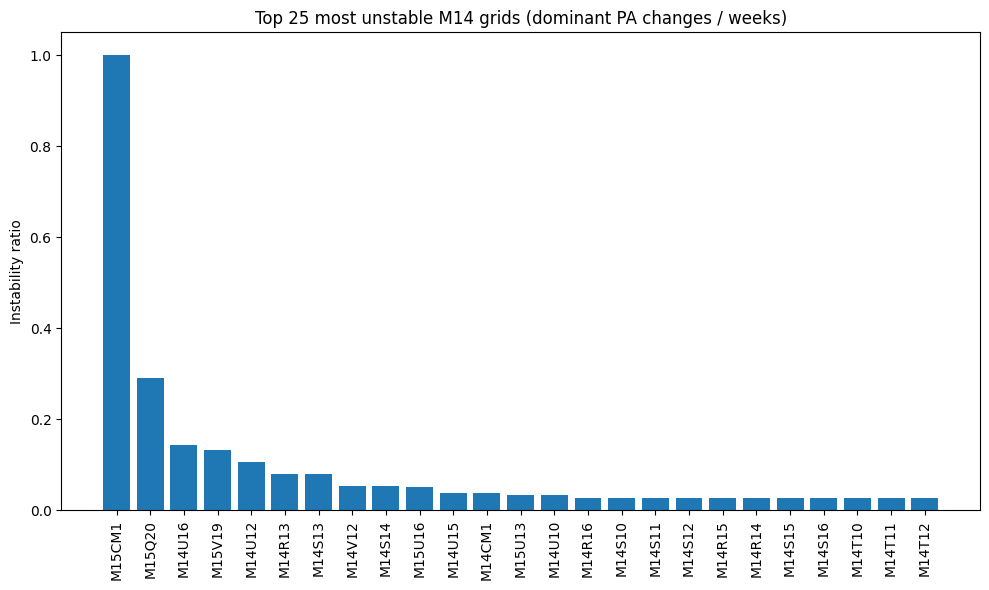

In [10]:
import matplotlib.pyplot as plt

# compute instability
df["prev_pa"] = df.groupby("sales_location_id")["pa_no"].shift(1)
df["changed"] = df["pa_no"] != df["prev_pa"]

instability = (
    df.groupby("sales_location_id")
    .agg(n_weeks=("year_week","nunique"), n_changes=("changed","sum"))
    .reset_index()
)
instability["instability_ratio"] = instability["n_changes"] / instability["n_weeks"]

# plot top unstable grids
topN = 25
plot_inst = instability.sort_values("instability_ratio", ascending=False).head(topN)

plt.figure(figsize=(10, 6))
plt.bar(plot_inst["sales_location_id"], plot_inst["instability_ratio"])
plt.xticks(rotation=90)
plt.title(f"Top {topN} most unstable M14 grids (dominant PA changes / weeks)")
plt.ylabel("Instability ratio")
plt.tight_layout()
plt.show()


In [11]:
unstable_grids = instability.sort_values("instability_ratio", ascending=False)

display(unstable_grids.head(10))


,sales_location_id,n_weeks,n_changes,instability_ratio
38,M15CM1,1,1,1.000000
41,M15Q20,38,11,0.289474
33,M14U16,7,1,0.142857
70,M15V19,38,5,0.131579
30,M14U12,38,4,0.105263
11,M14R13,38,3,0.078947
18,M14S13,38,3,0.078947
36,M14V12,38,2,0.052632
19,M14S14,38,2,0.052632
59,M15U16,20,1,0.050000


## estimate how ofter they change

In [12]:
df["changed"] = df["pa_no"] != df["pa_no"].shift()
df = df.loc[df.year_week >='2024-36']
change_weeks = (
    df[df["changed"]]
    .groupby("sales_location_id")["year_week"]
    .count()
    .reset_index(name="n_changes")
)

weeks_total = (
    df
    .groupby("sales_location_id")["year_week"]
    .nunique()
    .reset_index(name="n_weeks")
)

stability = change_weeks.merge(weeks_total, on="sales_location_id")
stability["avg_weeks_per_change"] = stability["n_weeks"] / stability["n_changes"]


In [13]:
stability.avg_weeks_per_change.median()

38.0

In [14]:
df_m = dominant_pa[
    dominant_pa["sales_location_id"].str.startswith("M", na=False)
].copy()

df_m = df_m.sort_values(["sales_location_id", "year_week"])
#🧱 Step 2 — Detect dominance change week-to-week
df_m["prev_pa"] = (
    df_m
    .groupby("sales_location_id")["pa_no"]
    .shift(1)
)

df_m["changed"] = df_m["pa_no"] != df_m["prev_pa"]
#🧱 Step 3 — Instability index per grid
instability = (
    df_m
    .groupby("sales_location_id")
    .agg(
        n_weeks=("year_week", "nunique"),
        n_changes=("changed", "sum")
    )
    .reset_index()
)

df_m["changed"] = df_m["pa_no"] != df_m["pa_no"].shift()

change_weeks = (
    df_m[df_m["changed"]]
    .groupby("sales_location_id")["year_week"]
    .count()
    .reset_index(name="n_changes")
)

weeks_total = (
    df_m
    .groupby("sales_location_id")["year_week"]
    .nunique()
    .reset_index(name="n_weeks")
)

stability = change_weeks.merge(weeks_total, on="sales_location_id")
stability["avg_weeks_per_change"] = stability["n_weeks"] / stability["n_changes"]


In [15]:
stability.avg_weeks_per_change.median()

37.5